# Parameter sensitivity: are all three of `f_ref`, `f_ins`, `f_adv` needed?

| | parameter | acts on | range |
|---|---|---|---|
| `f_ref` | refreeze_frac | melt+rain entering the column → latent heat | 0 – 1 |
| `f_ins` | insul_scale | Calonne (2011) snow/firn conductivity (low = insulates more) | 0.3 – 2.0 |
| `f_adv` | advection_scale | depth-averaged ice velocity | 0.3 – 1.7 |

Four questions, in order. A parameter earns its place only if it passes all four.

| # | question | a parameter fails if |
|---|---|---|
| A | does it move the model at all? | its sensitivity is ~0 |
| B | can the data tell it apart from the others? | it is confounded, \|rho\| > 0.8 |
| C | does it act *differently* with depth? | its depth pattern duplicates another's |
| D | does it work in both regimes? | it is dead on firn or on ice |

Input: the 48-point Latin hypercube on Grenzgletscher (`grenz_tuning3`), 24 entities, real IDL runs
with the thermal spin-up on. No IDL is launched from this notebook.

In [1]:
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from icetemp.calibration import CalibrationConfig, CalibrationPipeline

# Either a single run, or several worker run_dirs of one sweep (they share a design and split
# its rows, so they merge by design index).
RUN_TAGS = ['alps_sensitivity_w0', 'alps_sensitivity_w1', 'alps_sensitivity_w2']
# RUN_TAGS = ['grenz_tuning3']        # single-glacier sweep, for comparison
ENSEMBLE = None   # None = every glacier present in the run; or a list of base_glacier_names

PARAM_NAMES = ('refreeze_frac', 'insul_scale', 'advection_scale')
LABELS = ('$f_{ref}$', '$f_{ins}$', '$f_{adv}$')
BOUNDS = {'refreeze_frac': (0.0, 1.0), 'insul_scale': (0.3, 2.0), 'advection_scale': (0.3, 1.7)}

In [2]:
base = CalibrationConfig.from_yaml('../config/bayescal_centraleurope_25glaciers.yaml')

def cfg_for(tag):
    return CalibrationConfig(region=base.region, include_estimated=base.include_estimated,
                             include_unassessed=base.include_unassessed, run_tag=tag,
                             calibration_source_dir=base.calibration_source_dir,
                             calibration_source_files=base.calibration_source_files)

pl = CalibrationPipeline(cfg_for(RUN_TAGS[0]))
pl.load_data()

# design.csv is identical across workers (same seed and size); outputs merge by design index.
design = pd.read_csv(Path(cfg_for(RUN_TAGS[0]).output_path) / 'design.csv')
outputs = {}
for tag in RUN_TAGS:
    d = Path(cfg_for(tag).output_path) / 'training_runs'
    for f in sorted(d.glob('design_*.output.pkl')):
        i = int(f.stem.split('_')[1].split('.')[0])
        with open(f, 'rb') as fh:
            outputs[i] = pickle.load(fh)

names = {n for o in outputs.values() for n in o}
glaciers = [g for g in pl.data_handler.calibration_glaciers if g.glacier_name in names]
if ENSEMBLE:
    glaciers = [g for g in glaciers if g.base_glacier_name in ENSEMBLE]

bases = sorted({g.base_glacier_name for g in glaciers})
print(f'{len(RUN_TAGS)} run dir(s) -> {len(outputs)}/{len(design)} design points')
print(f'{len(bases)} glaciers, {len(glaciers)} entities, {sum(g.n_obs for g in glaciers)} obs')
print('  ' + ', '.join(bases))

Calibration glaciers: 116 (equilibrium=true: 56, estimated: 36, unassessed/blank: 24)
  with accumulation-zone (firn) obs: 89
  with ablation-zone (ice) obs:      27
  with data below 30 m:              37
  largest depth-bin pooling factor:  40776 raw readings -> 1 point (continuous-logger dedup)
Prediction (all glenglat) glaciers:  211
3 run dir(s) -> 29/32 design points
7 glaciers, 66 entities, 776 obs
  Glacier de Tête Rousse, Glacier des Bossons, Gornergletscher, Grenzgletscher, Hintereisferner, Hohsaasgletscher, Vadret dal Corvatsch


In [3]:
def regime(g):
    """Entity regime from its own observations."""
    if g.has_firn_obs and g.has_ice_obs:
        return 'mixed'
    return 'firn' if g.has_firn_obs else 'ice'


def assemble(glacier):
    """-> (X, Y, depths) for one entity: design rows with usable output, the modelled profiles,
    and the depth grid. Depths unresolved in ANY run (the -99 sentinel, i.e. below that band's
    ice thickness) are dropped so every column is comparable across design points."""
    rows_theta, rows_T, depths_ref = [], [], None
    for i in sorted(outputs):
        got = outputs[i].get(glacier.glacier_name)
        if got is None:
            continue
        d, T = got
        if depths_ref is None:
            depths_ref = np.asarray(d, dtype=float)
        rows_theta.append(design.iloc[i].values)
        rows_T.append(np.asarray(T, dtype=float))
    if not rows_T:
        return None, None, None
    X = np.asarray(rows_theta, dtype=float)
    Y = np.asarray(rows_T, dtype=float)
    keep = np.all(np.isfinite(Y), axis=0)
    return X, Y[:, keep], depths_ref[keep]


assembled = {g.glacier_name: assemble(g) for g in glaciers}
usable = [g for g in glaciers if assembled[g.glacier_name][0] is not None]
print(f'{len(usable)}/{len(glaciers)} entities usable')

66/66 entities usable


## A — does each parameter move the model?

Column-mean temperature of each entity regressed on the three parameters, standardised so each
coefficient reads as **°C per 1 sd of that parameter**. A parameter that cannot move the model
shows ~0 everywhere.

In [4]:
rows = []
for g in usable:
    X, Y, depths = assembled[g.glacier_name]
    Xs = (X - X.mean(axis=0)) / X.std(axis=0)
    A = np.column_stack([np.ones(len(Xs)), Xs])
    coef, *_ = np.linalg.lstsq(A, Y.mean(axis=1), rcond=None)
    rows.append({'entity': g.glacier_name, 'glacier': g.base_glacier_name,
                 'elev': round(g.elevation), 'regime': regime(g),
                 'n_obs': g.n_obs, 'T_spread': np.ptp(Y.mean(axis=1)),
                 **{p: c for p, c in zip(PARAM_NAMES, coef[1:])}})

effects = pd.DataFrame(rows).sort_values('elev')
print('degC per 1 sd of parameter, on the column-mean temperature:')
display(effects.round(3))

print('\npooled over all entities (median |effect|):')
for p in PARAM_NAMES:
    print(f'  {p:16s} {effects[p].abs().median():6.3f} degC/sd'
          + ('   <-- effectively inert' if effects[p].abs().median() < 0.05 else ''))

degC per 1 sd of parameter, on the column-mean temperature:


,entity,glacier,elev,regime,n_obs,T_spread,refreeze_frac,insul_scale,advection_scale
26,Grenzgletscher@2015,Grenzgletscher,2015,ice,10,0.776,0.067,-0.051,0.034
27,Grenzgletscher@2505,Grenzgletscher,2500,ice,12,1.574,0.125,-0.021,0.118
28,Grenzgletscher@2525,Grenzgletscher,2527,ice,14,1.548,0.125,-0.021,0.110
23,Gornergletscher@2525,Gornergletscher,2529,ice,9,1.548,0.125,-0.021,0.110
24,Gornergletscher@2545,Gornergletscher,2540,ice,9,1.716,0.140,-0.024,0.116
...,...,...,...,...,...,...,...,...,...
46,Grenzgletscher@4455,Grenzgletscher,4450,firn,63,3.064,0.420,-0.512,0.138
47,Grenzgletscher@4465,Grenzgletscher,4468,firn,19,3.089,0.412,-0.532,0.138
48,Grenzgletscher@4475,Grenzgletscher,4470,firn,24,6.929,1.158,-1.223,0.277
49,Grenzgletscher@4485,Grenzgletscher,4482,firn,18,7.180,1.212,-1.271,0.269



pooled over all entities (median |effect|):
  refreeze_frac     0.609 degC/sd
  insul_scale       0.689 degC/sd
  advection_scale   0.160 degC/sd


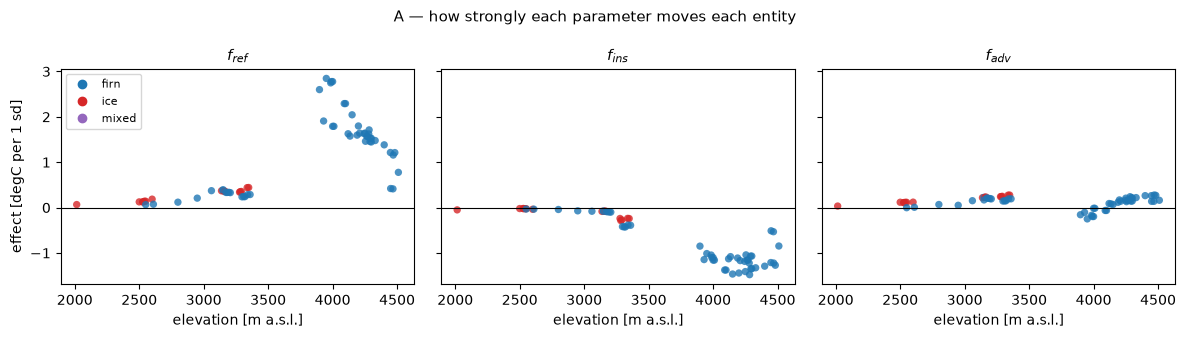

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
for ax, p, lab in zip(axes, PARAM_NAMES, LABELS):
    ax.axhline(0, color='k', lw=.8)
    for g in usable:
        r = regime(g)
        ax.scatter(g.elevation, effects.loc[effects.entity == g.glacier_name, p],
                   s=28, alpha=.8, edgecolor='none',
                   color={'firn': 'tab:blue', 'ice': 'tab:red', 'mixed': 'tab:purple'}[r])
    ax.set_xlabel('elevation [m a.s.l.]')
    ax.set_title(lab, fontsize=11)
axes[0].set_ylabel('effect [degC per 1 sd]')
handles = [plt.Line2D([], [], marker='o', ls='', color=c, label=l)
           for l, c in [('firn', 'tab:blue'), ('ice', 'tab:red'), ('mixed', 'tab:purple')]]
axes[0].legend(handles=handles, fontsize=8)
fig.suptitle('A — how strongly each parameter moves each entity', fontsize=11)
fig.tight_layout()

## B — can the data separate them?

Sensitivity matrix `J` at the real observation depths, weighted by observation error, then the
Fisher information `J'J`. Two parameters the data cannot tell apart show |rho| near 1 and a large
condition number — meaning many different parameter combinations fit equally well.

In [6]:
def identifiability(X, Y, depths, glacier):
    x_sd = X.std(axis=0)
    Xs = (X - X.mean(axis=0)) / x_sd
    A = np.column_stack([np.ones(len(Xs)), Xs])
    coef, *_ = np.linalg.lstsq(A, Y, rcond=None)
    J_full = coef[1:].T                                  # (n_depth, 3) degC per 1 sd

    idx = [int(np.argmin(np.abs(depths - d))) for d in glacier.depths]
    J = J_full[idx]
    sig = np.asarray(glacier.sigma, dtype=float)[:len(idx)]
    Jw = J / sig[:, None]

    F = Jw.T @ Jw
    svals = np.linalg.svd(Jw, compute_uv=False)
    cond = svals.max() / svals.min() if svals.min() > 0 else np.inf
    try:
        cov = np.linalg.inv(F)
    except np.linalg.LinAlgError:
        cov = np.linalg.pinv(F)
    var = np.diag(cov)
    corr = np.full_like(cov, np.nan)
    if (var > 0).all():
        sd = np.sqrt(var)
        corr = cov / np.outer(sd, sd)
    return {'J_full': J_full, 'J': J, 'svals': svals, 'cond': cond, 'corr': corr,
            'se_native': np.sqrt(np.abs(var)) * x_sd,
            'rms_sensitivity': np.sqrt((J ** 2).mean(axis=0))}


diag = {g.glacier_name: identifiability(*assembled[g.glacier_name], g) for g in usable}

rows = []
for g in usable:
    d = diag[g.glacier_name]
    c = d['corr']
    rows.append({'entity': g.glacier_name, 'glacier': g.base_glacier_name,
                 'elev': round(g.elevation), 'regime': regime(g),
                 'cond(J)': d['cond'],
                 **{f'rms_{p}': s for p, s in zip(('ref', 'ins', 'adv'), d['rms_sensitivity'])},
                 'rho_ref_ins': c[0, 1], 'rho_ref_adv': c[0, 2], 'rho_ins_adv': c[1, 2]})
ident = pd.DataFrame(rows).sort_values('elev')
display(ident.round(2))

print('confounded pairs (|rho| > 0.8):')
for pair, col in [('f_ref <-> f_ins', 'rho_ref_ins'), ('f_ref <-> f_adv', 'rho_ref_adv'),
                  ('f_ins <-> f_adv', 'rho_ins_adv')]:
    n = int((ident[col].abs() > 0.8).sum())
    print(f'  {pair:18s} {n:2d}/{len(ident)} entities   median rho = {ident[col].median():+.2f}')

,entity,glacier,elev,regime,cond(J),rms_ref,rms_ins,rms_adv,rho_ref_ins,rho_ref_adv,rho_ins_adv
26,Grenzgletscher@2015,Grenzgletscher,2015,ice,137.50,0.02,0.01,0.02,1.00,0.91,0.92
27,Grenzgletscher@2505,Grenzgletscher,2500,ice,59.38,0.06,0.03,0.08,0.75,-0.99,-0.85
28,Grenzgletscher@2525,Grenzgletscher,2527,ice,60.68,0.07,0.02,0.08,0.92,-1.00,-0.95
23,Gornergletscher@2525,Gornergletscher,2529,ice,75.61,0.08,0.02,0.08,0.97,-1.00,-0.98
24,Gornergletscher@2545,Gornergletscher,2540,ice,364.66,0.06,0.01,0.06,0.99,-1.00,-1.00
...,...,...,...,...,...,...,...,...,...,...,...
46,Grenzgletscher@4455,Grenzgletscher,4450,firn,122.21,0.31,0.38,0.10,-0.90,-0.96,0.99
47,Grenzgletscher@4465,Grenzgletscher,4468,firn,89.65,0.20,0.18,0.05,0.82,0.72,0.98
48,Grenzgletscher@4475,Grenzgletscher,4470,firn,141.22,1.00,1.09,0.25,0.47,0.15,0.95
49,Grenzgletscher@4485,Grenzgletscher,4482,firn,158.20,1.13,1.20,0.25,0.42,-0.83,0.15


confounded pairs (|rho| > 0.8):
  f_ref <-> f_ins    51/66 entities   median rho = +0.97
  f_ref <-> f_adv    47/66 entities   median rho = -0.00
  f_ins <-> f_adv    51/66 entities   median rho = +0.34


## C — do they act differently with depth?

The decisive test. Two parameters that produce the **same shape** of temperature change with depth
are interchangeable, however strong each one is on its own. Curves that cross or peak at different
depths mean the profile can separate them.

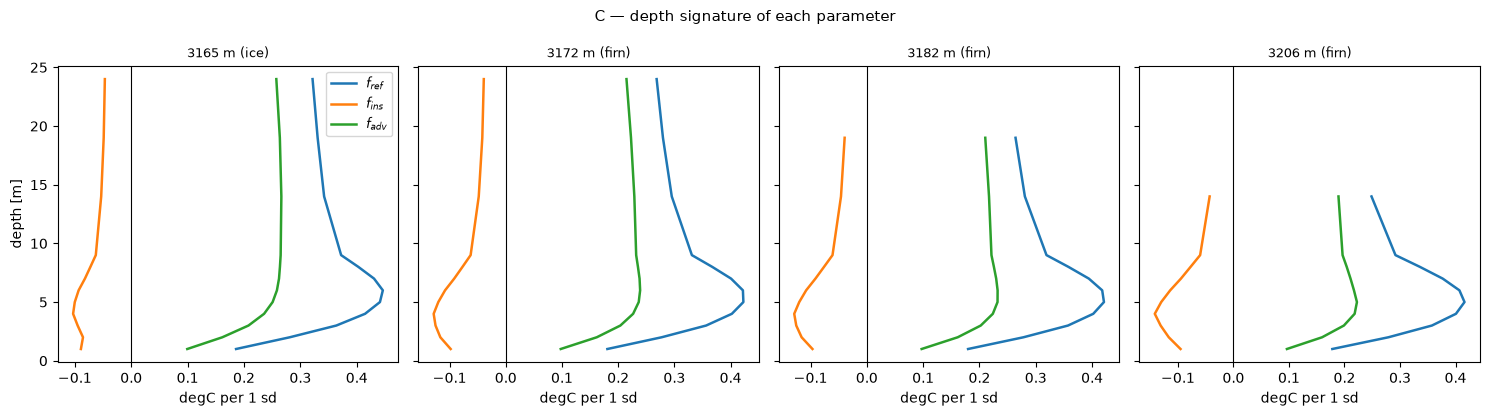

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4.2), sharey=True)
sel = [g for g in usable if g.n_obs >= 15][:4] or usable[:4]
for ax, g in zip(axes, sel):
    X, Y, depths = assembled[g.glacier_name]
    J = diag[g.glacier_name]['J_full']
    for k, (p, lab) in enumerate(zip(PARAM_NAMES, LABELS)):
        ax.plot(J[:, k], depths, lw=1.8, label=lab)
    ax.axvline(0, color='k', lw=.8)
    ax.invert_yaxis()
    ax.set_title(f'{round(g.elevation)} m ({regime(g)})', fontsize=9)
    ax.set_xlabel('degC per 1 sd')
axes[0].set_ylabel('depth [m]')
axes[0].legend(fontsize=9)
fig.suptitle('C — depth signature of each parameter', fontsize=11)
fig.tight_layout()

In [8]:
# Shape similarity: cosine between two parameters' depth-response vectors, per entity.
# +-1 = identical shape (redundant), 0 = orthogonal (independent information).
rows = []
for g in usable:
    J = diag[g.glacier_name]['J_full']
    def cos(a, b):
        na, nb = np.linalg.norm(J[:, a]), np.linalg.norm(J[:, b])
        return np.nan if na == 0 or nb == 0 else float(J[:, a] @ J[:, b] / (na * nb))
    rows.append({'entity': g.glacier_name, 'glacier': g.base_glacier_name,
                 'elev': round(g.elevation), 'regime': regime(g),
                 'ref~ins': cos(0, 1), 'ref~adv': cos(0, 2), 'ins~adv': cos(1, 2)})
shape = pd.DataFrame(rows).sort_values('elev')
display(shape.round(2))
print('median shape similarity (|cos| > 0.95 would mean redundant):')
for c in ('ref~ins', 'ref~adv', 'ins~adv'):
    print(f'  {c:9s} {shape[c].median():+.2f}')

,entity,glacier,elev,regime,ref~ins,ref~adv,ins~adv
26,Grenzgletscher@2015,Grenzgletscher,2015,ice,-0.95,0.99,-0.96
27,Grenzgletscher@2505,Grenzgletscher,2500,ice,-0.60,0.97,-0.42
28,Grenzgletscher@2525,Grenzgletscher,2527,ice,-0.59,0.98,-0.44
23,Gornergletscher@2525,Gornergletscher,2529,ice,-0.59,0.98,-0.44
24,Gornergletscher@2545,Gornergletscher,2540,ice,-0.59,0.98,-0.46
...,...,...,...,...,...,...,...
46,Grenzgletscher@4455,Grenzgletscher,4450,firn,-0.99,0.99,-1.00
47,Grenzgletscher@4465,Grenzgletscher,4468,firn,-0.99,1.00,-1.00
48,Grenzgletscher@4475,Grenzgletscher,4470,firn,-1.00,0.99,-1.00
49,Grenzgletscher@4485,Grenzgletscher,4482,firn,-1.00,1.00,-1.00


median shape similarity (|cos| > 0.95 would mean redundant):
  ref~ins   -0.97
  ref~adv   +0.97
  ins~adv   -0.91


## D — does each parameter work in both regimes?

`perm_frac` was retired partly because it was dead on bare ice. This checks whether `f_ref`
inherited that weakness: refreezing needs both meltwater and pore space.

f_ref        f_ins        f_adv      
       median count median count median count
regime                                       
firn    1.226    51  0.955    51  0.172    51
ice     0.327    15  0.049    15  0.245    15

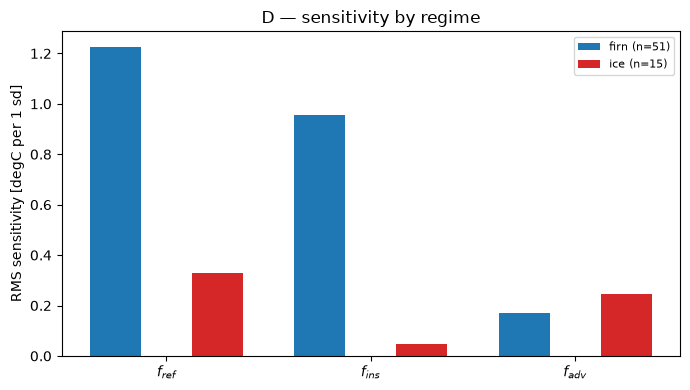

In [9]:
by_regime = (ident.assign(**{'f_ref': ident.rms_ref, 'f_ins': ident.rms_ins, 'f_adv': ident.rms_adv})
             .groupby('regime')[['f_ref', 'f_ins', 'f_adv']]
             .agg(['median', 'count']))
display(by_regime.round(3))

fig, ax = plt.subplots(figsize=(7, 4))
w, xs = 0.25, np.arange(len(PARAM_NAMES))
for k, (r, colr) in enumerate([('firn', 'tab:blue'), ('mixed', 'tab:purple'), ('ice', 'tab:red')]):
    sub = ident[ident.regime == r]
    if sub.empty:
        continue
    ax.bar(xs + (k - 1) * w, [sub.rms_ref.median(), sub.rms_ins.median(), sub.rms_adv.median()],
           width=w, color=colr, label=f'{r} (n={len(sub)})')
ax.set_xticks(xs)
ax.set_xticklabels(LABELS)
ax.set_ylabel('RMS sensitivity [degC per 1 sd]')
ax.set_title('D — sensitivity by regime')
ax.legend(fontsize=8)
fig.tight_layout()

## Verdict

Fill from the tables above. A parameter is kept only if it clears all four.

| | A: moves the model | B: separable | C: own depth signature | D: both regimes | keep? |
|---|---|---|---|---|---|
| `f_ref` | | | | | |
| `f_ins` | | | | | |
| `f_adv` | | | | | |

Rules of thumb used above: inert if median effect < 0.05 °C/sd; confounded if \|rho\| > 0.8;
redundant if \|cos\| > 0.95; ill-conditioned if cond(J) > 100.